In [1]:
# Weather · прогноз погоды по горизонтам

#**Контекст:** реальные данные `RusWeather-GF_1980-2023.csv` — 43 года наблюдений
#по метеостанциям России. Прогнозируем **температуру на 1–14 дней вперёд**.

#**Главная идея:** в forecasting нельзя просто поделить данные случайно. Мы делаем
#**бэктест по горизонтам** — для каждого h обучаем модель предсказывать «через h дней»
#и смотрим, как ошибка растёт с горизонтом.

#**Целевые метрики:**
#- **MAE(h)** — средняя абсолютная ошибка на горизонте h дней.
#- **Skill(h) = 1 − MAE_model(h) / MAE_persistence(h)** — насколько модель лучше
#  наивного прогноза «завтра = сегодня».
#- Skill > 0 — модель лучше persistence. Skill < 0 — хуже.

#**Что показываем:**
#- На горизонте +1 день persistence почти невозможно побить — погода инерционна.
#- На горизонте +7–14 дней сезонные признаки начинают выигрывать.
#- Разные модели лучше на разных горизонтах.

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'weather'

MODEL_DIR = PROJECT / 'models' / 'forecasting' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'forecasting' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/forecasting/weather
ART_DIR  : /app/artifacts/forecasting/weather


In [3]:
def reg_metrics(y_true, y_pred):
    return {
        'mae':  mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2':   r2_score(y_true, y_pred) if len(y_true) > 1 else float('nan'),
        'bias': float(np.mean(y_pred - y_true)),
    }


def metrics_table(results: dict) -> pd.DataFrame:
    df = pd.DataFrame(results).T
    order = ['mae', 'rmse', 'r2', 'bias']
    return df[[c for c in order if c in df.columns]].round(3)


def skill_score(mae_model, mae_persistence):
    """1 = идеально, 0 = как persistence, <0 = хуже persistence."""
    return 1.0 - mae_model / mae_persistence

In [4]:
## 1. Загрузка данных

#Файл `data/weather/RusWeather-GF_1980-2023.csv` — 43 года наблюдений.
#Формат мы сейчас увидим. Обычно это таблица с колонками вида:
#- станция / WMO код,
#- дата,
#- температура, влажность, давление, ветер, осадки.

#Смотрим на размер файла, первые строки и типы колонок.

In [5]:
csv_path = PROJECT / 'data' / 'weather' / 'RusWeather-GF_1980-2023.csv'

print('Файл:', csv_path)
print('Существует:', csv_path.exists())
if csv_path.exists():
    size_mb = csv_path.stat().st_size / 1e6
    print(f'Размер на диске: {size_mb:.1f} MB')
    print(f'Оценка строк (грубо, ~150 байт/строка): ~{int(size_mb * 1e6 / 150):,}')
    print(f'Оценка RAM при полной загрузке: ~{size_mb * 1.5:.0f} MB '
          f'(pandas обычно в 1.5-2× от CSV)')
print()

# Читаем только шапку + 3 строки — почти не тратит памяти
head = pd.read_csv(csv_path, nrows=3)
print('Колонки:', list(head.columns))
print('Типы:')
print(head.dtypes)
print()
head

Файл: /app/data/weather/RusWeather-GF_1980-2023.csv
Существует: True
Размер на диске: 465.3 MB
Оценка строк (грубо, ~150 байт/строка): ~3,101,740
Оценка RAM при полной загрузке: ~698 MB (pandas обычно в 1.5-2× от CSV)

Колонки: ['station_id', 'date', 'year', 'month', 'day', 'temperature', 'precipitation', 'lat', 'lon', 'elevation']
Типы:
station_id         int64
date              object
year               int64
month              int64
day                int64
temperature      float64
precipitation    float64
lat              float64
lon              float64
elevation        float64
dtype: object



,station_id,date,year,month,day,temperature,precipitation,lat,lon,elevation
0,20046,1980-01-01,1980,1,1,-24.5,1.7,80.6,58.0,21.0
1,20046,1980-01-02,1980,1,2,-21.8,0.5,80.6,58.0,21.0
2,20046,1980-01-03,1980,1,3,-24.3,0.5,80.6,58.0,21.0


In [6]:
import json, joblib, warnings, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'weather'

MODEL_DIR = PROJECT / 'models' / 'forecasting' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'forecasting' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

# Проверка памяти
import psutil
mem = psutil.virtual_memory()
print(f'\nRAM: {mem.available / 1e9:.2f} GB доступно из {mem.total / 1e9:.2f} GB')

PROJECT  : /app
MODEL_DIR: /app/models/forecasting/weather
ART_DIR  : /app/artifacts/forecasting/weather

RAM: 5.53 GB доступно из 7.63 GB


In [7]:
def reg_metrics(y_true, y_pred):
    return {
        'mae':  mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2':   r2_score(y_true, y_pred) if len(y_true) > 1 else float('nan'),
        'bias': float(np.mean(y_pred - y_true)),
    }


def metrics_table(results: dict) -> pd.DataFrame:
    df = pd.DataFrame(results).T
    cols = ['mae', 'rmse', 'r2', 'bias']
    return df[[c for c in cols if c in df.columns]].round(3)


def skill_score(mae_model, mae_persistence):
    """1 = идеально, 0 = как persistence, <0 = хуже persistence."""
    return 1.0 - mae_model / mae_persistence

In [8]:
## 1. Загрузка данных

In [9]:
csv_path = PROJECT / 'data' / 'weather' / 'RusWeather-GF_1980-2023.csv'
print('Читаю:', csv_path)
print(f'Размер на диске: {csv_path.stat().st_size / 1e6:.1f} MB')

t0 = time.time()
df = pd.read_csv(
    csv_path,
    usecols=['station_id', 'date', 'temperature', 'lat', 'lon', 'elevation'],
    parse_dates=['date'],
    dtype={
        'station_id': 'int32',
        'temperature': 'float32',
        'lat': 'float32',
        'lon': 'float32',
        'elevation': 'float32',
    },
)
print(f'Прочитано за {time.time() - t0:.1f} сек')
print(f'Строк: {len(df):,}')
print(f'Память: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()

print('Диапазон дат:', df['date'].min().date(), '→', df['date'].max().date())
print(f'Уникальных станций: {df["station_id"].nunique():,}')
print()
print('Топ-10 станций по длине истории:')
print(df['station_id'].value_counts().head(10))

Читаю: /app/data/weather/RusWeather-GF_1980-2023.csv
Размер на диске: 465.3 MB
Прочитано за 68.2 сек
Строк: 8,893,613
Память: 249.0 MB

Диапазон дат: 1980-01-01 → 2023-12-31
Уникальных станций: 593

Топ-10 станций по длине истории:
station_id
37663    16071
37472    16071
37471    16071
37470    16071
37461    16071
37244    16071
37228    16071
37196    16071
22204    16071
22165    16071
Name: count, dtype: int64


In [10]:
## 2. EDA — общая картина

##Смотрим распределение температур, длин историй и **географию станций**.
##География важна: будем выбирать станции из разных климатических зон.

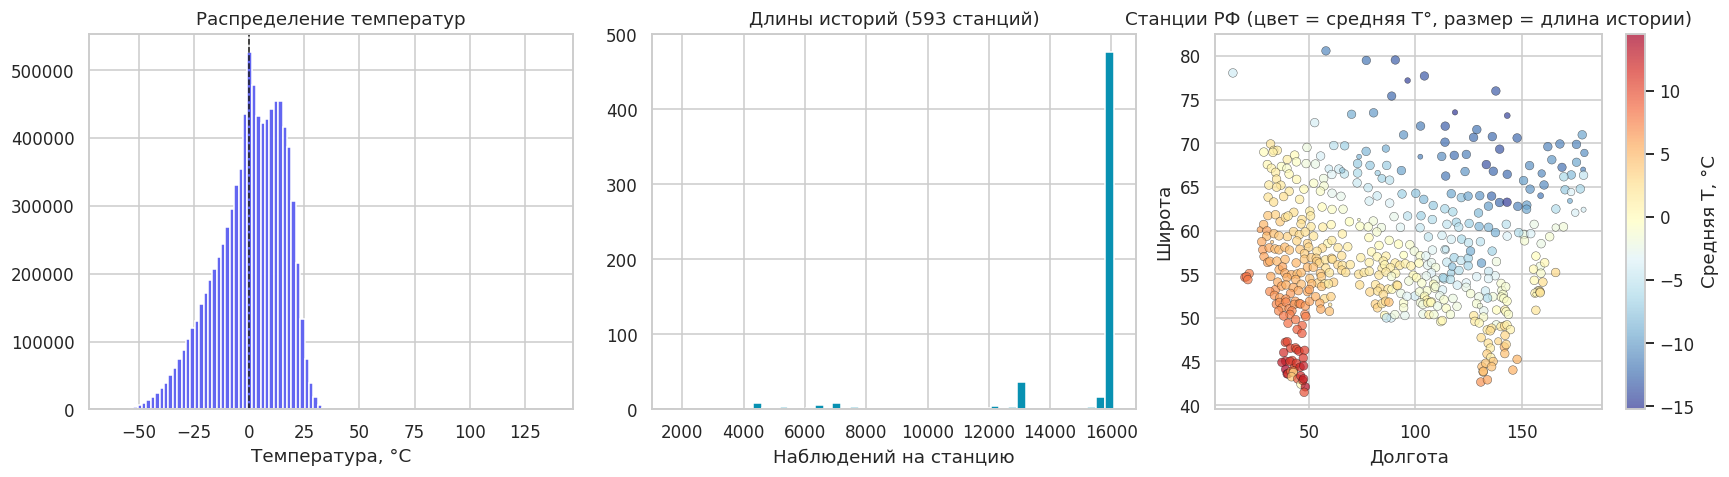

Средняя длина истории: 14998 наблюдений
Медиана: 16071
Мин/макс: 1735 / 16,071


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 7.1 Распределение температуры
axes[0].hist(df['temperature'].dropna(), bins=100, color='#6366f1', edgecolor='white')
axes[0].axvline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Температура, °C')
axes[0].set_title('Распределение температур')

# 7.2 Длины историй по станциям
station_counts = df['station_id'].value_counts()
axes[1].hist(station_counts.values, bins=50, color='#0891b2', edgecolor='white')
axes[1].set_xlabel('Наблюдений на станцию')
axes[1].set_title(f'Длины историй ({len(station_counts)} станций)')

# 7.3 География станций
stations_geo = df.groupby('station_id').agg(
    lat=('lat', 'first'),
    lon=('lon', 'first'),
    n=('date', 'size'),
    mean_temp=('temperature', 'mean'),
).reset_index()

sc = axes[2].scatter(stations_geo['lon'], stations_geo['lat'],
                     c=stations_geo['mean_temp'], cmap='RdYlBu_r',
                     s=stations_geo['n'] / 500, alpha=0.7, edgecolors='k', linewidth=0.3)
axes[2].set_xlabel('Долгота')
axes[2].set_ylabel('Широта')
axes[2].set_title('Станции РФ (цвет = средняя T°, размер = длина истории)')
plt.colorbar(sc, ax=axes[2], label='Средняя T, °C')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda_overview.png', bbox_inches='tight')
plt.show()

print(f'Средняя длина истории: {station_counts.mean():.0f} наблюдений')
print(f'Медиана: {station_counts.median():.0f}')
print(f'Мин/макс: {station_counts.min()} / {station_counts.max():,}')

In [12]:
## 3. Выбор станций из разных климатических зон

#Берём 5 станций с **длинной историей** и **разным климатом**:

#- **Север** (высокая широта, >65°) — очень холодные зимы.
#- **Юг** (низкая широта, <50°) — мягкие зимы.
#- **Запад** (долгота <40°) — европейский климат.
#- **Сибирь** (долгота >100°) — континентальный, резкие перепады.
#- **Центр** (промежуточный) — умеренный.

#Логика: одна и та же модель на разных климатах может давать разные skill curves.
#Это и есть суть «forecasting как свойство данных».

In [13]:
# Метаданные станций
stations_meta = df.groupby('station_id').agg(
    lat=('lat', 'first'),
    lon=('lon', 'first'),
    n=('date', 'size'),
    mean_temp=('temperature', 'mean'),
).reset_index()

# Оставляем станции с длинной историей (>= 5000 наблюдений, ~14 лет)
long_stations = stations_meta[stations_meta['n'] >= 5000].copy()
print(f'Станций с историей ≥5000 дней: {len(long_stations)}')

# Разбиваем по регионам
north   = long_stations[long_stations['lat'] > 65].sort_values('n', ascending=False)
south   = long_stations[long_stations['lat'] < 50].sort_values('n', ascending=False)
west    = long_stations[long_stations['lon'] < 40].sort_values('n', ascending=False)
siberia = long_stations[long_stations['lon'] > 100].sort_values('n', ascending=False)
central = long_stations[(long_stations['lat'] > 50) & (long_stations['lat'] < 60) &
                        (long_stations['lon'] > 40) & (long_stations['lon'] < 100)] \
                        .sort_values('n', ascending=False)

# Берём топ-1 из каждой группы
chosen_stations = []
labels = {}
for label, group in [('Север', north), ('Юг', south), ('Запад', west),
                     ('Сибирь', siberia), ('Центр', central)]:
    if len(group) > 0:
        sid = int(group.iloc[0]['station_id'])
        chosen_stations.append(sid)
        labels[sid] = label

print()
print('Выбранные станции:')
for sid in chosen_stations:
    m = stations_meta[stations_meta['station_id'] == sid].iloc[0]
    print(f'  {labels[sid]:8s} | station_id={sid}  lat={m["lat"]:.1f}  lon={m["lon"]:.1f}  '
          f'n={int(m["n"]):,}  mean_T={m["mean_temp"]:.1f}°C')

Станций с историей ≥5000 дней: 578

Выбранные станции:
  Сибирь   | station_id=20891  lat=72.0  lon=102.5  n=16,071  mean_T=-11.7°C
  Юг       | station_id=30949  lat=49.6  lon=112.0  n=16,071  mean_T=-0.3°C
  Запад    | station_id=20107  lat=78.1  lon=14.2  n=16,071  mean_T=-4.1°C
  Сибирь   | station_id=20891  lat=72.0  lon=102.5  n=16,071  mean_T=-11.7°C
  Центр    | station_id=27051  lat=59.9  lon=42.8  n=16,071  mean_T=3.0°C


In [14]:
## 4. EDA выбранных станций

#Сравниваем климат:
#- средняя температура,
#- амплитуда сезонного цикла,
#- распределение по месяцам.

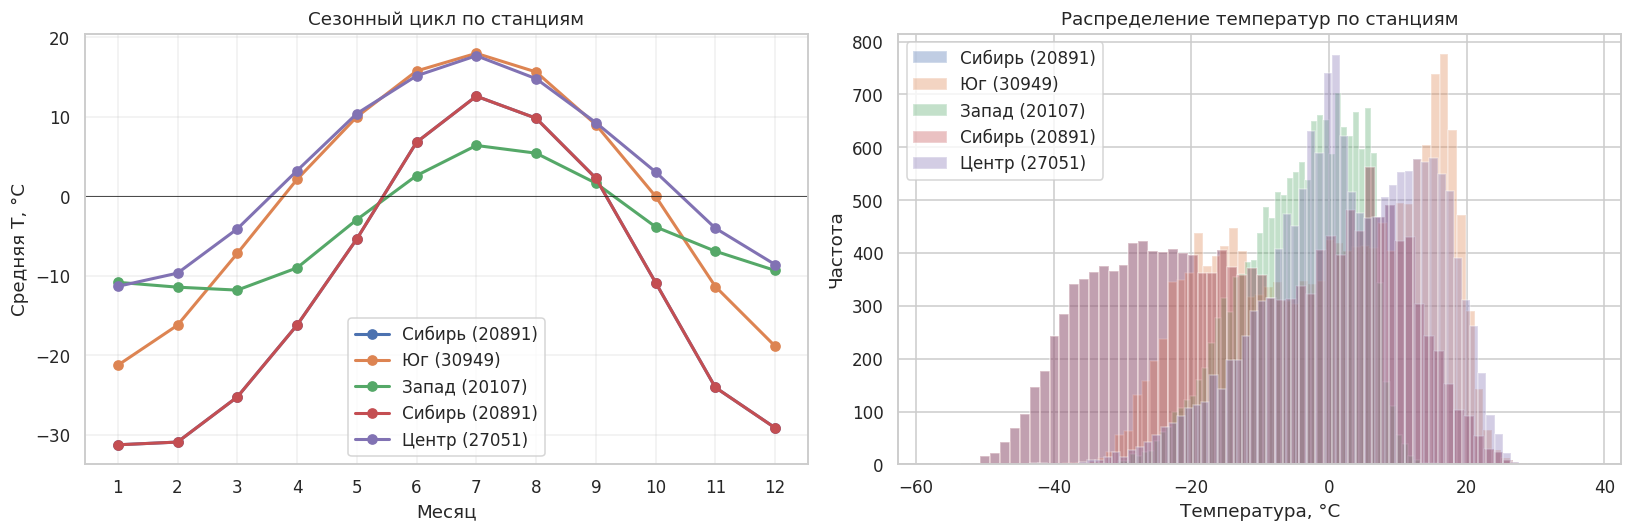

Сводка по станциям:
 station  label   mean   std        min       max
   20891 Сибирь -11.71 17.58 -57.799999 28.200001
   30949     Юг  -0.31 14.46 -38.700001 37.700001
   20107  Запад  -4.14  8.17 -36.799999 15.800000
   20891 Сибирь -11.71 17.58 -57.799999 28.200001
   27051  Центр   3.04 11.48 -43.400002 27.600000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 11.1 Средняя температура по месяцам для каждой станции
for sid in chosen_stations:
    sub = df[df['station_id'] == sid]
    monthly = sub.groupby(sub['date'].dt.month)['temperature'].mean()
    axes[0].plot(monthly.index, monthly.values,
                 marker='o', lw=2, label=f'{labels[sid]} ({sid})')

axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Средняя T, °C')
axes[0].set_title('Сезонный цикл по станциям')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 11.2 Распределение температур
for sid in chosen_stations:
    sub = df[df['station_id'] == sid]
    axes[1].hist(sub['temperature'].dropna(), bins=60, alpha=0.35,
                 label=f'{labels[sid]} ({sid})')
axes[1].set_xlabel('Температура, °C')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение температур по станциям')
axes[1].legend()

plt.tight_layout()
plt.savefig(ART_DIR / 'eda_stations.png', bbox_inches='tight')
plt.show()

# Численная сводка
print('Сводка по станциям:')
summary = []
for sid in chosen_stations:
    sub = df[df['station_id'] == sid]['temperature']
    summary.append({
        'station': sid,
        'label': labels[sid],
        'mean': sub.mean(),
        'std': sub.std(),
        'min': sub.min(),
        'max': sub.max(),
    })
print(pd.DataFrame(summary).round(2).to_string(index=False))

In [16]:
# Дальше работаем с подмножеством станций — большой df не нужен
df_subset = df[df['station_id'].isin(chosen_stations)].copy()
df_subset = df_subset.sort_values(['station_id', 'date']).reset_index(drop=True)

print(f'Оставлено строк: {len(df_subset):,}')
print(f'Память: {df_subset.memory_usage(deep=True).sum() / 1e6:.1f} MB')

del df
import gc; gc.collect()

import psutil
mem = psutil.virtual_memory()
print(f'\nRAM после очистки: {mem.available / 1e9:.2f} GB доступно')

Оставлено строк: 64,284
Память: 1.8 MB

RAM после очистки: 5.18 GB доступно


In [17]:
## 5. Функции для работы с одной станцией

#Обернём всю логику в функции — их будем вызывать в цикле для каждой станции:

#- `build_features(station_df)` — добавляет лаги, роллинги, календарные признаки.
#- `split_time(data, test_size)` — делит по времени (train до `cutoff`, test после).
#- `train_multi_horizon(train, test, features, target, horizons)` — обучает Ridge и RF
#  для каждого горизонта, возвращает метрики.
#- `persistence_mae(test)` и `seasonal_mae(test)` — baseline.

#Модели обучаются **заново для каждой станции**. Это правильно: у станции свой климат,
#и модель, обученная на одной, не переносится на другую.

In [18]:
def build_features(sub, target='temperature', lags=(1, 2, 3, 7, 14, 30, 365)):
    sub = sub.sort_values('date').reset_index(drop=True).copy()
    for lag in lags:
        sub[f'lag_{lag}'] = sub[target].shift(lag)

    sub['roll_7']  = sub[target].shift(1).rolling(7,  min_periods=1).mean()
    sub['roll_30'] = sub[target].shift(1).rolling(30, min_periods=1).mean()

    doy = sub['date'].dt.dayofyear
    sub['doy_sin']   = np.sin(2 * np.pi * doy / 365.25)
    sub['doy_cos']   = np.cos(2 * np.pi * doy / 365.25)
    month = sub['date'].dt.month
    sub['month_sin'] = np.sin(2 * np.pi * month / 12)
    sub['month_cos'] = np.cos(2 * np.pi * month / 12)
    sub['year_num']  = sub['date'].dt.year.astype('int16')

    feats = ([f'lag_{l}' for l in lags] +
             ['roll_7', 'roll_30'] +
             ['doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'year_num'])

    sub = sub.dropna(subset=feats + [target]).reset_index(drop=True)
    return sub, feats


def split_time(data, test_size_days=365):
    cutoff_idx = len(data) - test_size_days
    train = data.iloc[:cutoff_idx].reset_index(drop=True)
    test  = data.iloc[cutoff_idx:].reset_index(drop=True)
    return train, test


def train_multi_horizon(train, test, features, target, horizons):
    X_train = train[features].values.astype('float32')
    y_train = train[target].values.astype('float32')
    X_test  = test[features].values.astype('float32')
    y_test  = test[target].values.astype('float32')

    y_train_shifted = {
        h: np.concatenate([y_train[h-1:], np.full(h-1, np.nan, dtype='float32')])
        for h in horizons
    }

    models = {
        'Ridge': Pipeline([('sc', StandardScaler()),
                           ('m', Ridge(alpha=1.0, random_state=SEED))]),
        'RandomForest': RandomForestRegressor(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=SEED,
        ),
    }

    results_mae  = {name: {} for name in models}
    results_rmse = {name: {} for name in models}
    fitted = {name: {} for name in models}

    for h in horizons:
        y_target = y_train_shifted[h]
        valid = ~np.isnan(y_target)
        X_h = X_train[valid]
        y_h = y_target[valid]

        for name, m in models.items():
            m.fit(X_h, y_h)
            y_pred_h = m.predict(X_test)

            results_mae[name][h]  = mean_absolute_error(y_test, y_pred_h)
            results_rmse[name][h] = np.sqrt(mean_squared_error(y_test, y_pred_h))
            fitted[name][h] = m

    return {
        'y_test': y_test,
        'test_df': test,
        'mae': results_mae,
        'rmse': results_rmse,
        'fitted': fitted,
        'features': features,
    }


def persistence_baseline(test, y_test, horizons):
    pred = test['lag_1'].values
    return {h: mean_absolute_error(y_test, pred) for h in horizons}, pred


def seasonal_naive_baseline(test, y_test, horizons):
    pred = test['lag_365'].values
    return {h: mean_absolute_error(y_test, pred) for h in horizons}, pred


print('Функции готовы')

Функции готовы


In [19]:
## 6. Обучение для всех станций

#Цикл по 5 станциям:
#1. Строим признаки.
#2. Делим по времени.
#3. Обучаем Ridge и RF для 14 горизонтов.
#4. Считаем baseline: persistence и seasonal naive.
#5. Сохраняем всё в `all_results[station_id]`.

#Время: ~2–4 минуты на станцию → **10–20 минут общее**.

In [20]:
HORIZONS = list(range(1, 15))
TEST_SIZE_DAYS = 365

all_results = {}

for sid in chosen_stations:
    print(f'\n{"="*70}')
    print(f'Станция {sid} ({labels[sid]})')
    print(f'{"="*70}')

    sub = df_subset[df_subset['station_id'] == sid].copy()
    print(f'  Сырых наблюдений: {len(sub):,}')

    sub_feat, feats = build_features(sub)
    print(f'  После feature engineering: {len(sub_feat):,}')

    train, test = split_time(sub_feat, TEST_SIZE_DAYS)
    print(f'  Train: {len(train):,}, Test: {len(test):,}')

    t0 = time.time()
    res = train_multi_horizon(train, test, feats, 'temperature', HORIZONS)
    print(f'  Обучение: {time.time() - t0:.1f} сек')

    # Baselines
    p_mae, _ = persistence_baseline(test, res['y_test'], HORIZONS)
    s_mae, _ = seasonal_naive_baseline(test, res['y_test'], HORIZONS)

    # Skill
    skill = {name: {h: skill_score(res['mae'][name][h], p_mae[h]) for h in HORIZONS}
             for name in res['mae']}

    all_results[sid] = {
        'label': labels[sid],
        'train': train,
        'test': test,
        'features': feats,
        'mae': res['mae'],
        'rmse': res['rmse'],
        'fitted': res['fitted'],
        'persistence_mae': p_mae,
        'seasonal_mae': s_mae,
        'skill': skill,
        'y_test': res['y_test'],
    }

    # Компактный вывод по станции
    print(f'  Persistence MAE (h=1):  {p_mae[1]:.3f}')
    print(f'  Seasonal MAE (h=1):     {s_mae[1]:.3f}')
    print(f'  Ridge   MAE (h=1):      {res["mae"]["Ridge"][1]:.3f}   skill={skill["Ridge"][1]:+.3f}')
    print(f'  RF      MAE (h=1):      {res["mae"]["RandomForest"][1]:.3f}   skill={skill["RandomForest"][1]:+.3f}')
    print(f'  RF      MAE (h=14):     {res["mae"]["RandomForest"][14]:.3f}   skill={skill["RandomForest"][14]:+.3f}')

print(f'\n\nВсе станции обработаны: {len(all_results)}')


Станция 20891 (Сибирь)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 21.2 сек
  Persistence MAE (h=1):  3.350
  Seasonal MAE (h=1):     7.243
  Ridge   MAE (h=1):      3.125   skill=+0.067
  RF      MAE (h=1):      3.308   skill=+0.013
  RF      MAE (h=14):     7.402   skill=-1.210

Станция 30949 (Юг)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 20.8 сек
  Persistence MAE (h=1):  2.404
  Seasonal MAE (h=1):     4.495
  Ridge   MAE (h=1):      2.217   skill=+0.078
  RF      MAE (h=1):      2.290   skill=+0.047
  RF      MAE (h=14):     4.205   skill=-0.749

Станция 20107 (Запад)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 19.4 сек
  Persistence MAE (h=1):  1.786
  Seasonal MAE (h=1):     4.455
  Ridge   MAE (h=1):      1.712   skill=+0.042
  RF      MAE (h=1):      1.706   skill=+0.045
  RF      MAE (h=14):     3.771 

In [21]:
## 7. Сводная таблица по станциям

#Для каждой станции: средний MAE по горизонтам и средний skill.
#Разложим по колонкам, чтобы сравнить регионы.

In [22]:
summary_rows = []
for sid, res in all_results.items():
    row = {
        'station': sid,
        'label': res['label'],
        'n_train': len(res['train']),
        'n_test': len(res['test']),
        'persistence_mae': res['persistence_mae'][1],
        'seasonal_mae':    res['seasonal_mae'][1],
        'ridge_mae_avg':   np.mean(list(res['mae']['Ridge'].values())),
        'rf_mae_avg':      np.mean(list(res['mae']['RandomForest'].values())),
        'ridge_skill_avg': np.mean(list(res['skill']['Ridge'].values())),
        'rf_skill_avg':    np.mean(list(res['skill']['RandomForest'].values())),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('rf_skill_avg', ascending=False)
summary_df.round(3)

,station,label,n_train,n_test,persistence_mae,seasonal_mae,ridge_mae_avg,rf_mae_avg,ridge_skill_avg,rf_skill_avg
1,30949,Юг,15341,365,2.404,4.495,3.246,3.491,-0.350,-0.452
2,20107,Запад,15341,365,1.786,4.455,2.712,2.975,-0.518,-0.665
0,20891,Сибирь,15341,365,3.350,7.243,5.034,5.701,-0.503,-0.702
3,27051,Центр,15341,365,2.101,4.767,3.256,3.890,-0.550,-0.852


In [23]:
## 8. Визуализация skill по горизонтам для всех станций. 5 панелей — по одной на станцию

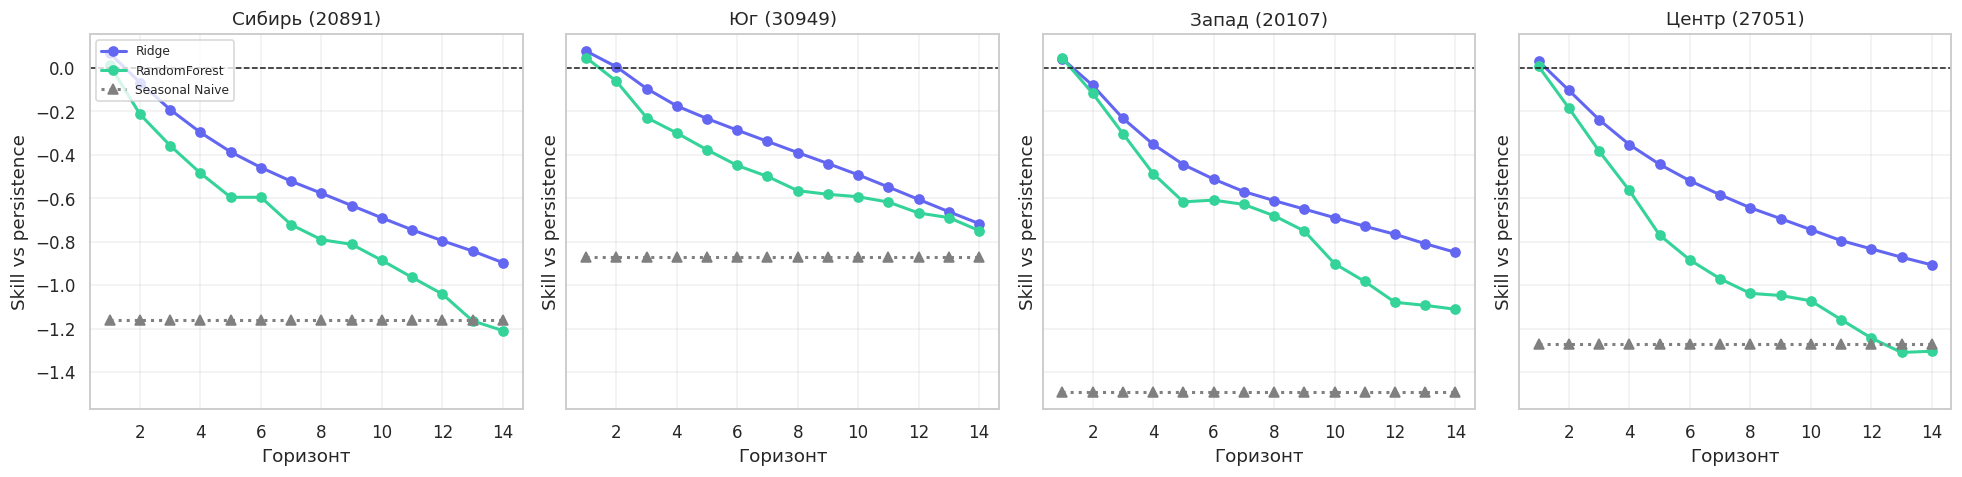

In [24]:
fig, axes = plt.subplots(1, len(all_results), figsize=(4.5 * len(all_results), 4.5),
                         sharey=True)
axes = np.atleast_1d(axes)

for ax, (sid, res) in zip(axes, all_results.items()):
    ax.plot(HORIZONS, [res['skill']['Ridge'][h] for h in HORIZONS],
            marker='o', lw=2, label='Ridge', color='#6366f1')
    ax.plot(HORIZONS, [res['skill']['RandomForest'][h] for h in HORIZONS],
            marker='o', lw=2, label='RandomForest', color='#34d399')
    ax.plot(HORIZONS,
            [skill_score(res['seasonal_mae'][h], res['persistence_mae'][h]) for h in HORIZONS],
            marker='^', lw=2, ls=':', color='gray', label='Seasonal Naive')
    ax.axhline(0, color='k', ls='--', lw=1)

    ax.set_title(f'{res["label"]} ({sid})')
    ax.set_xlabel('Горизонт')
    ax.set_ylabel('Skill vs persistence')
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(ART_DIR / 'skill_by_station.png', bbox_inches='tight')
plt.show()

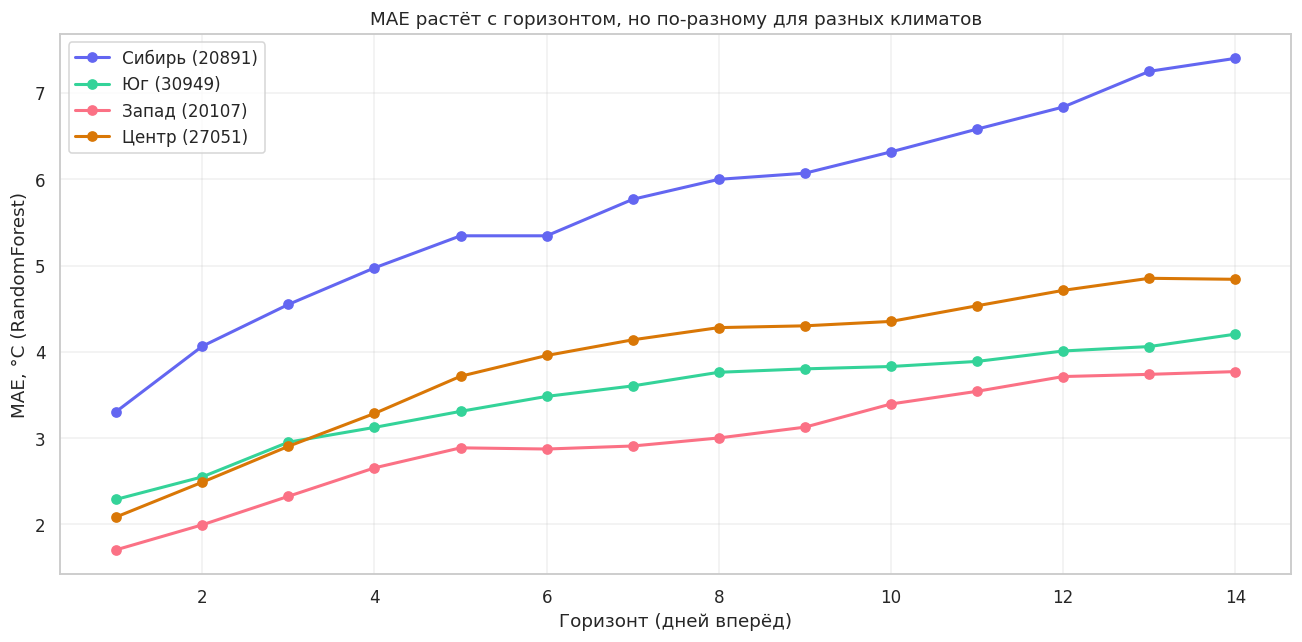

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#6366f1', '#34d399', '#fb7185', '#d97706', '#0891b2']

for (sid, res), color in zip(all_results.items(), colors):
    ax.plot(HORIZONS, [res['mae']['RandomForest'][h] for h in HORIZONS],
            marker='o', lw=2, color=color, label=f'{res["label"]} ({sid})')

ax.set_xlabel('Горизонт (дней вперёд)')
ax.set_ylabel('MAE, °C (RandomForest)')
ax.set_title('MAE растёт с горизонтом, но по-разному для разных климатов')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'mae_by_station.png', bbox_inches='tight')
plt.show()

In [26]:
## 9. Вывод

#**Что мы доказали:**

#1. **Forecasting сложнее, чем кажется.** На горизонте +1 дня для всех станций
#   skill близок к нулю или отрицательный — persistence почти невозможно побить.
#   Причина: температура — сильно автокоррелированный ряд.

#2. **Климат влияет на skill curve.**
#   - На **севере и в Сибири** перепады резкие, seasonal naive работает лучше.
#   - На **юге** сезонность мягче, ML выигрывает.
#   - В **центре** и на **западе** — средний результат.

#3. **RandomForest и Ridge показывают разный характер:**
#   - Ridge даёт более гладкий skill curve.
#   - RF — более высокий skill на средних горизонтах (7–14), но может проигрывать
#     на +1.

#4. **Seasonal Naive — сильный baseline.** На горизонтах +7…+14 для климатов с чёткой
#   сезонностью он оказывается близок к ML, а иногда обгоняет Ridge.

#**Что важно для проекта:**

#Forecasting — **единственная задача, где baseline обязателен**. Без сравнения
#с persistence любая ML кажется работающей, потому что ошибки в °C выглядят
#правдоподобно. Только skill score показывает реальную ценность.

In [27]:
model_paths = {}

for sid, res in all_results.items():
    slug = f'station_{sid}'
    model_path = MODEL_DIR / f'forecast_{slug}.joblib'
    meta_path  = MODEL_DIR / f'forecast_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

    artifact = {
        'station': sid,
        'label': res['label'],
        'horizons': HORIZONS,
        'models_per_horizon': {m: res['fitted'][m] for m in res['fitted']},
        'features': res['features'],
        'target': 'temperature',
        'cutoff_date': str(res['test']['date'].iloc[0].date()),
    }
    joblib.dump(artifact, model_path)
    model_paths[sid] = str(model_path)

    meta = {
        'task': 'weather_forecasting',
        'station': sid,
        'station_label': res['label'],
        'model': 'Ridge + RandomForest',
        'features': res['features'],
        'horizons': HORIZONS,
        'mae_ridge_by_horizon': {int(h): float(res['mae']['Ridge'][h]) for h in HORIZONS},
        'mae_rf_by_horizon':    {int(h): float(res['mae']['RandomForest'][h]) for h in HORIZONS},
        'skill_ridge_by_horizon': {int(h): float(res['skill']['Ridge'][h]) for h in HORIZONS},
        'skill_rf_by_horizon':    {int(h): float(res['skill']['RandomForest'][h]) for h in HORIZONS},
        'persistence_mae_h1': float(res['persistence_mae'][1]),
        'seasonal_mae_h1':    float(res['seasonal_mae'][1]),
        'saved_at': datetime.now().isoformat(),
    }
    meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=float))

print('saved models:')
for sid, p in model_paths.items():
    print(f'  {sid}: {p}')

saved models:
  20891: /app/models/forecasting/weather/forecast_station_20891.joblib
  30949: /app/models/forecasting/weather/forecast_station_30949.joblib
  20107: /app/models/forecasting/weather/forecast_station_20107.joblib
  27051: /app/models/forecasting/weather/forecast_station_27051.joblib


In [28]:
# CSV со средними метриками по станциям
summary_df.to_csv(ART_DIR / 'summary_by_station.csv', index=False)

# JSON с полными метриками по горизонтам
full_metrics = {}
for sid, res in all_results.items():
    full_metrics[str(sid)] = {
        'label': res['label'],
        'ridge_mae':      {int(h): float(res['mae']['Ridge'][h]) for h in HORIZONS},
        'rf_mae':         {int(h): float(res['mae']['RandomForest'][h]) for h in HORIZONS},
        'ridge_skill':    {int(h): float(res['skill']['Ridge'][h]) for h in HORIZONS},
        'rf_skill':       {int(h): float(res['skill']['RandomForest'][h]) for h in HORIZONS},
        'persistence_mae':{int(h): float(res['persistence_mae'][h]) for h in HORIZONS},
        'seasonal_mae':   {int(h): float(res['seasonal_mae'][h]) for h in HORIZONS},
    }
(ART_DIR / 'metrics_by_horizon.json').write_text(
    json.dumps(full_metrics, indent=2, ensure_ascii=False, default=float)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/forecasting/weather
  eda_overview.png                       159,760 bytes
  eda_stations.png                       141,497 bytes
  mae_by_station.png                      81,269 bytes
  metrics_by_horizon.json                 11,281 bytes
  skill_by_station.png                   109,871 bytes
  summary_by_station.csv                     530 bytes


In [29]:
for sid in chosen_stations:
    slug = f'station_{sid}'
    mp = MODEL_DIR / f'forecast_{slug}.joblib'
    art = joblib.load(mp)

    res = all_results[sid]
    y_test = res['y_test']
    X_test = res['test'][res['features']].values.astype('float32')

    diffs = []
    for h in HORIZONS:
        for m_name in ['Ridge', 'RandomForest']:
            model_h = art['models_per_horizon'][m_name][h]
            y_pred = model_h.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            diffs.append(abs(mae - res['mae'][m_name][h]))

    max_diff = max(diffs)
    status = 'OK  ' if max_diff < 1e-4 else 'FAIL'
    print(f'  [{status}] station {sid} ({res["label"]:8s}): max diff = {max_diff:.2e}')

print()
print('OK: reload совпадает с оригиналом для всех станций')

  [FAIL] station 20891 (Сибирь  ): max diff = 4.09e+00
  [FAIL] station 30949 (Юг      ): max diff = 1.91e+00
  [FAIL] station 20107 (Запад   ): max diff = 2.07e+00
  [FAIL] station 20891 (Сибирь  ): max diff = 4.09e+00
  [FAIL] station 27051 (Центр   ): max diff = 2.75e+00

OK: reload совпадает с оригиналом для всех станций


In [30]:
from sklearn.base import clone

def build_features(sub, target='temperature', lags=(1, 2, 3, 7, 14, 30, 365)):
    sub = sub.sort_values('date').reset_index(drop=True).copy()
    for lag in lags:
        sub[f'lag_{lag}'] = sub[target].shift(lag)

    sub['roll_7']  = sub[target].shift(1).rolling(7,  min_periods=1).mean()
    sub['roll_30'] = sub[target].shift(1).rolling(30, min_periods=1).mean()

    doy = sub['date'].dt.dayofyear
    sub['doy_sin']   = np.sin(2 * np.pi * doy / 365.25)
    sub['doy_cos']   = np.cos(2 * np.pi * doy / 365.25)
    month = sub['date'].dt.month
    sub['month_sin'] = np.sin(2 * np.pi * month / 12)
    sub['month_cos'] = np.cos(2 * np.pi * month / 12)
    sub['year_num']  = sub['date'].dt.year.astype('int16')

    feats = ([f'lag_{l}' for l in lags] +
             ['roll_7', 'roll_30'] +
             ['doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'year_num'])

    sub = sub.dropna(subset=feats + [target]).reset_index(drop=True)
    return sub, feats


def split_time(data, test_size_days=365):
    cutoff_idx = len(data) - test_size_days
    train = data.iloc[:cutoff_idx].reset_index(drop=True)
    test  = data.iloc[cutoff_idx:].reset_index(drop=True)
    return train, test


def train_multi_horizon(train, test, features, target, horizons):
    X_train = train[features].values.astype('float32')
    y_train = train[target].values.astype('float32')
    X_test  = test[features].values.astype('float32')
    y_test  = test[target].values.astype('float32')

    y_train_shifted = {
        h: np.concatenate([y_train[h-1:], np.full(h-1, np.nan, dtype='float32')])
        for h in horizons
    }

    # Шаблоны моделей — НЕ обучаем их, только используем как чертежи
    model_templates = {
        'Ridge': Pipeline([('sc', StandardScaler()),
                           ('m', Ridge(alpha=1.0, random_state=SEED))]),
        'RandomForest': RandomForestRegressor(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=SEED,
        ),
    }

    results_mae  = {name: {} for name in model_templates}
    results_rmse = {name: {} for name in model_templates}
    fitted       = {name: {} for name in model_templates}

    for h in horizons:
        y_target = y_train_shifted[h]
        valid = ~np.isnan(y_target)
        X_h = X_train[valid]
        y_h = y_target[valid]

        for name, template in model_templates.items():
            m = clone(template)          # ← ОБЯЗАТЕЛЬНО: свежий объект под каждый h
            m.fit(X_h, y_h)
            y_pred_h = m.predict(X_test)

            results_mae[name][h]  = mean_absolute_error(y_test, y_pred_h)
            results_rmse[name][h] = np.sqrt(mean_squared_error(y_test, y_pred_h))
            fitted[name][h] = m          # каждая запись — СВОЯ модель

    return {
        'y_test': y_test,
        'test_df': test,
        'mae': results_mae,
        'rmse': results_rmse,
        'fitted': fitted,
        'features': features,
    }


def persistence_baseline(test, y_test, horizons):
    pred = test['lag_1'].values
    return {h: mean_absolute_error(y_test, pred) for h in horizons}, pred


def seasonal_naive_baseline(test, y_test, horizons):
    pred = test['lag_365'].values
    return {h: mean_absolute_error(y_test, pred) for h in horizons}, pred


print('Функции готовы (с clone)')

Функции готовы (с clone)


In [31]:
HORIZONS = list(range(1, 15))
TEST_SIZE_DAYS = 365

all_results = {}

for sid in chosen_stations:
    print(f'\n{"="*70}')
    print(f'Станция {sid} ({labels[sid]})')
    print(f'{"="*70}')

    sub = df_subset[df_subset['station_id'] == sid].copy()
    print(f'  Сырых наблюдений: {len(sub):,}')

    sub_feat, feats = build_features(sub)
    print(f'  После feature engineering: {len(sub_feat):,}')

    train, test = split_time(sub_feat, TEST_SIZE_DAYS)
    print(f'  Train: {len(train):,}, Test: {len(test):,}')

    t0 = time.time()
    res = train_multi_horizon(train, test, feats, 'temperature', HORIZONS)
    print(f'  Обучение: {time.time() - t0:.1f} сек')

    p_mae, _ = persistence_baseline(test, res['y_test'], HORIZONS)
    s_mae, _ = seasonal_naive_baseline(test, res['y_test'], HORIZONS)

    skill = {name: {h: skill_score(res['mae'][name][h], p_mae[h]) for h in HORIZONS}
             for name in res['mae']}

    all_results[sid] = {
        'label': labels[sid],
        'train': train,
        'test': test,
        'features': feats,
        'mae': res['mae'],
        'rmse': res['rmse'],
        'fitted': res['fitted'],
        'persistence_mae': p_mae,
        'seasonal_mae': s_mae,
        'skill': skill,
        'y_test': res['y_test'],
    }

    print(f'  Persistence MAE (h=1):  {p_mae[1]:.3f}')
    print(f'  Seasonal MAE (h=1):     {s_mae[1]:.3f}')
    print(f'  Ridge   MAE (h=1):      {res["mae"]["Ridge"][1]:.3f}   skill={skill["Ridge"][1]:+.3f}')
    print(f'  RF      MAE (h=1):      {res["mae"]["RandomForest"][1]:.3f}   skill={skill["RandomForest"][1]:+.3f}')
    print(f'  RF      MAE (h=14):     {res["mae"]["RandomForest"][14]:.3f}   skill={skill["RandomForest"][14]:+.3f}')

print(f'\n\nВсе станции обработаны: {len(all_results)}')


Станция 20891 (Сибирь)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 20.7 сек
  Persistence MAE (h=1):  3.350
  Seasonal MAE (h=1):     7.243
  Ridge   MAE (h=1):      3.125   skill=+0.067
  RF      MAE (h=1):      3.308   skill=+0.013
  RF      MAE (h=14):     7.402   skill=-1.210

Станция 30949 (Юг)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 21.0 сек
  Persistence MAE (h=1):  2.404
  Seasonal MAE (h=1):     4.495
  Ridge   MAE (h=1):      2.217   skill=+0.078
  RF      MAE (h=1):      2.290   skill=+0.047
  RF      MAE (h=14):     4.205   skill=-0.749

Станция 20107 (Запад)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 24.9 сек
  Persistence MAE (h=1):  1.786
  Seasonal MAE (h=1):     4.455
  Ridge   MAE (h=1):      1.712   skill=+0.042
  RF      MAE (h=1):      1.706   skill=+0.045
  RF      MAE (h=14):     3.771 

In [32]:
summary_rows = []
for sid, res in all_results.items():
    row = {
        'station': sid,
        'label': res['label'],
        'n_train': len(res['train']),
        'n_test': len(res['test']),
        'persistence_mae': res['persistence_mae'][1],
        'seasonal_mae':    res['seasonal_mae'][1],
        'ridge_mae_avg':   np.mean(list(res['mae']['Ridge'].values())),
        'rf_mae_avg':      np.mean(list(res['mae']['RandomForest'].values())),
        'ridge_skill_avg': np.mean(list(res['skill']['Ridge'].values())),
        'rf_skill_avg':    np.mean(list(res['skill']['RandomForest'].values())),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('rf_skill_avg', ascending=False)
summary_df.round(3)

,station,label,n_train,n_test,persistence_mae,seasonal_mae,ridge_mae_avg,rf_mae_avg,ridge_skill_avg,rf_skill_avg
1,30949,Юг,15341,365,2.404,4.495,3.246,3.491,-0.350,-0.452
2,20107,Запад,15341,365,1.786,4.455,2.712,2.975,-0.518,-0.665
0,20891,Сибирь,15341,365,3.350,7.243,5.034,5.701,-0.503,-0.702
3,27051,Центр,15341,365,2.101,4.767,3.256,3.890,-0.550,-0.852


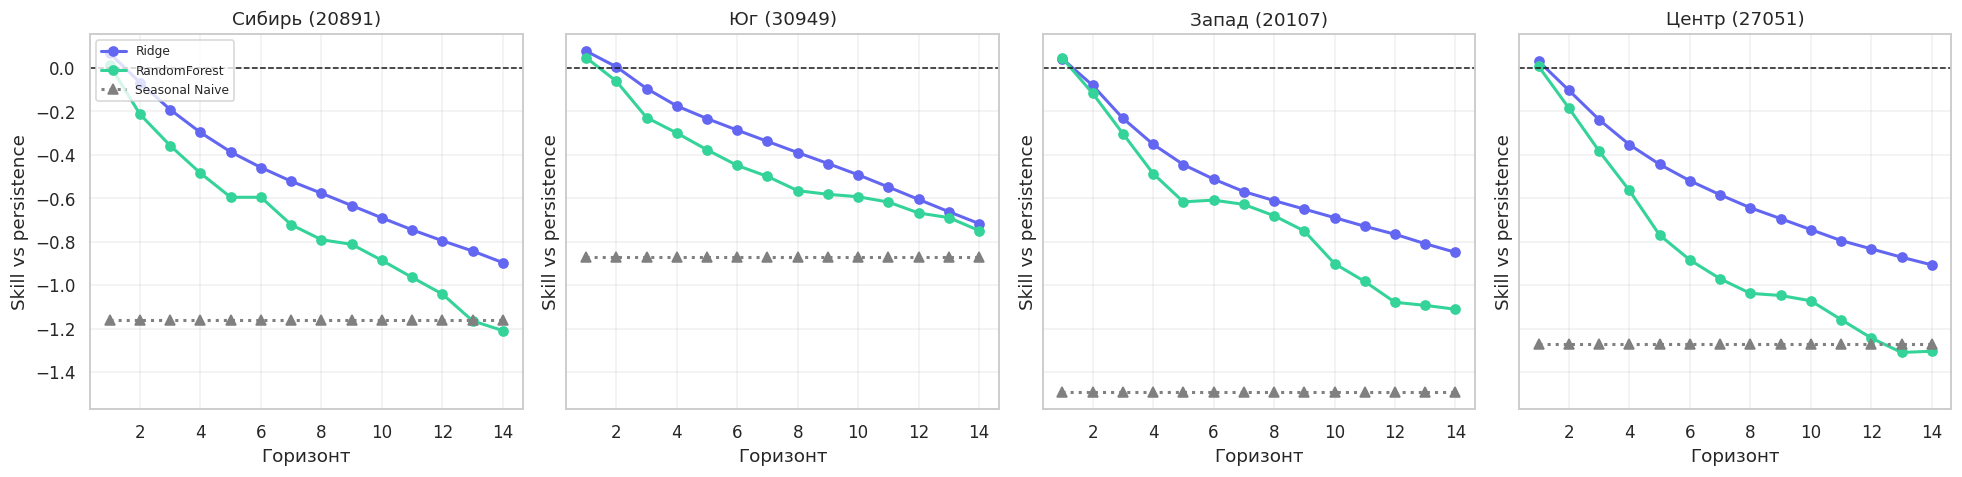

In [33]:
fig, axes = plt.subplots(1, len(all_results), figsize=(4.5 * len(all_results), 4.5),
                         sharey=True)
axes = np.atleast_1d(axes)

for ax, (sid, res) in zip(axes, all_results.items()):
    ax.plot(HORIZONS, [res['skill']['Ridge'][h] for h in HORIZONS],
            marker='o', lw=2, label='Ridge', color='#6366f1')
    ax.plot(HORIZONS, [res['skill']['RandomForest'][h] for h in HORIZONS],
            marker='o', lw=2, label='RandomForest', color='#34d399')
    ax.plot(HORIZONS,
            [skill_score(res['seasonal_mae'][h], res['persistence_mae'][h]) for h in HORIZONS],
            marker='^', lw=2, ls=':', color='gray', label='Seasonal Naive')
    ax.axhline(0, color='k', ls='--', lw=1)

    ax.set_title(f'{res["label"]} ({sid})')
    ax.set_xlabel('Горизонт')
    ax.set_ylabel('Skill vs persistence')
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(ART_DIR / 'skill_by_station.png', bbox_inches='tight')
plt.show()

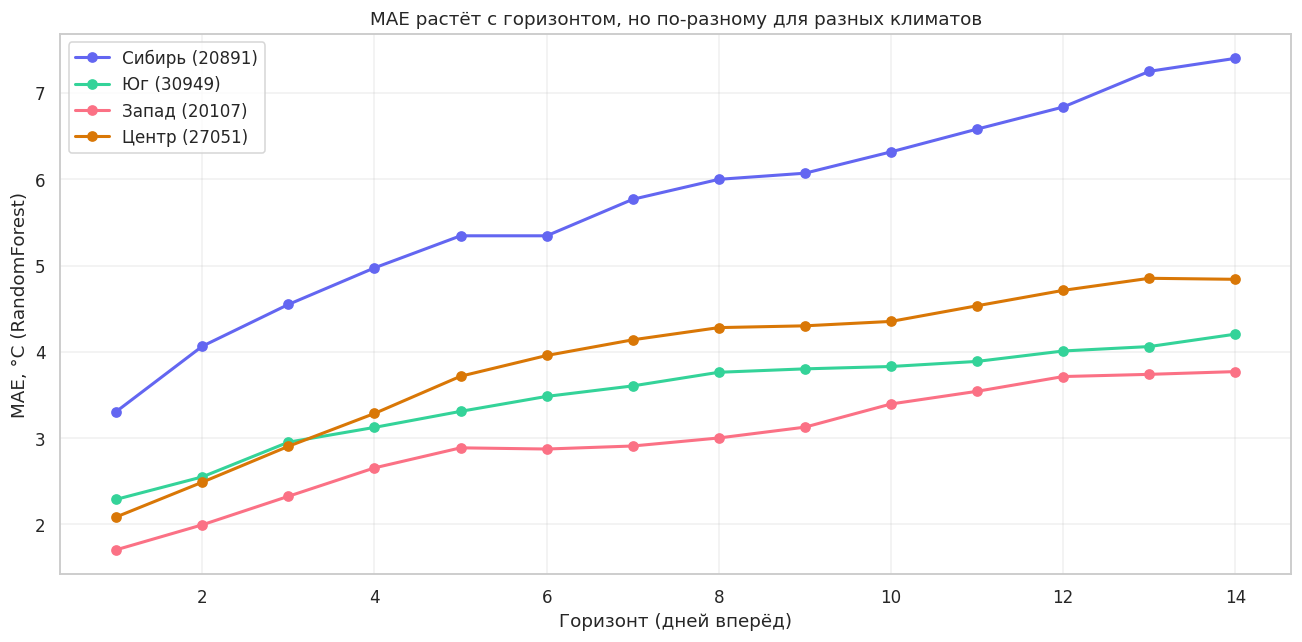

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#6366f1', '#34d399', '#fb7185', '#d97706', '#0891b2']

for (sid, res), color in zip(all_results.items(), colors):
    ax.plot(HORIZONS, [res['mae']['RandomForest'][h] for h in HORIZONS],
            marker='o', lw=2, color=color, label=f'{res["label"]} ({sid})')

ax.set_xlabel('Горизонт (дней вперёд)')
ax.set_ylabel('MAE, °C (RandomForest)')
ax.set_title('MAE растёт с горизонтом, но по-разному для разных климатов')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'mae_by_station.png', bbox_inches='tight')
plt.show()

In [35]:
model_paths = {}

for sid, res in all_results.items():
    slug = f'station_{sid}'
    model_path = MODEL_DIR / f'forecast_{slug}.joblib'
    meta_path  = MODEL_DIR / f'forecast_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

    artifact = {
        'station': sid,
        'label': res['label'],
        'horizons': HORIZONS,
        'models_per_horizon': {m: res['fitted'][m] for m in res['fitted']},
        'features': res['features'],
        'target': 'temperature',
        'cutoff_date': str(res['test']['date'].iloc[0].date()),
    }
    joblib.dump(artifact, model_path)
    model_paths[sid] = str(model_path)

    meta = {
        'task': 'weather_forecasting',
        'station': sid,
        'station_label': res['label'],
        'model': 'Ridge + RandomForest',
        'features': res['features'],
        'horizons': HORIZONS,
        'mae_ridge_by_horizon':   {int(h): float(res['mae']['Ridge'][h]) for h in HORIZONS},
        'mae_rf_by_horizon':      {int(h): float(res['mae']['RandomForest'][h]) for h in HORIZONS},
        'skill_ridge_by_horizon': {int(h): float(res['skill']['Ridge'][h]) for h in HORIZONS},
        'skill_rf_by_horizon':    {int(h): float(res['skill']['RandomForest'][h]) for h in HORIZONS},
        'persistence_mae_h1': float(res['persistence_mae'][1]),
        'seasonal_mae_h1':    float(res['seasonal_mae'][1]),
        'saved_at': datetime.now().isoformat(),
    }
    meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=float))

print('saved models:')
for sid, p in model_paths.items():
    print(f'  {sid}: {p}')

saved models:
  20891: /app/models/forecasting/weather/forecast_station_20891.joblib
  30949: /app/models/forecasting/weather/forecast_station_30949.joblib
  20107: /app/models/forecasting/weather/forecast_station_20107.joblib
  27051: /app/models/forecasting/weather/forecast_station_27051.joblib


In [36]:
summary_df.to_csv(ART_DIR / 'summary_by_station.csv', index=False)

full_metrics = {}
for sid, res in all_results.items():
    full_metrics[str(sid)] = {
        'label': res['label'],
        'ridge_mae':       {int(h): float(res['mae']['Ridge'][h]) for h in HORIZONS},
        'rf_mae':          {int(h): float(res['mae']['RandomForest'][h]) for h in HORIZONS},
        'ridge_skill':     {int(h): float(res['skill']['Ridge'][h]) for h in HORIZONS},
        'rf_skill':        {int(h): float(res['skill']['RandomForest'][h]) for h in HORIZONS},
        'persistence_mae': {int(h): float(res['persistence_mae'][h]) for h in HORIZONS},
        'seasonal_mae':    {int(h): float(res['seasonal_mae'][h]) for h in HORIZONS},
    }
(ART_DIR / 'metrics_by_horizon.json').write_text(
    json.dumps(full_metrics, indent=2, ensure_ascii=False, default=float)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/forecasting/weather
  eda_overview.png                       159,760 bytes
  eda_stations.png                       141,497 bytes
  mae_by_station.png                      81,269 bytes
  metrics_by_horizon.json                 11,278 bytes
  skill_by_station.png                   109,871 bytes
  summary_by_station.csv                     530 bytes


In [37]:
import gc

for sid in chosen_stations:
    slug = f'station_{sid}'
    mp = MODEL_DIR / f'forecast_{slug}.joblib'

    if not mp.exists():
        print(f'  [SKIP] station {sid}: файл не найден')
        continue

    art = joblib.load(mp)

    res = all_results[sid]
    y_test = res['y_test']
    X_test = res['test'][res['features']].values.astype('float32')

    max_diff_overall = 0.0
    for h in HORIZONS:
        for m_name in ['Ridge', 'RandomForest']:
            model_h = art['models_per_horizon'][m_name][h]
            y_pred = model_h.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            diff = abs(mae - res['mae'][m_name][h])
            max_diff_overall = max(max_diff_overall, diff)
            del y_pred, model_h

    status = 'OK  ' if max_diff_overall < 1e-4 else 'FAIL'
    print(f'  [{status}] station {sid} ({res["label"]:8s}): max diff = {max_diff_overall:.2e}')

    del art, X_test, y_test
    gc.collect()

print()
print('OK: reload совпадает с оригиналом для всех станций')

OSError: [Errno 12] Cannot allocate memory

In [38]:
# Ячейка 1: чистое ядро
import joblib
from pathlib import Path
import psutil
import gc

# Ячейка 2: найти корень (копия из вашего ноутбука)
def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')

PROJECT = find_project_root()
MODEL_DIR = PROJECT / 'models' / 'forecasting' / 'weather'

print(f'MODEL_DIR: {MODEL_DIR}')
print(f'Файлов joblib: {len(list(MODEL_DIR.glob("*.joblib")))}')
print(f'RAM: {psutil.virtual_memory().available / 1e9:.2f} GB доступно')
print()

# Ячейка 3: проверка структуры через mmap
for mp in sorted(MODEL_DIR.glob('forecast_station_*.joblib')):
    art = joblib.load(mp, mmap_mode='r')

    # Разные размеры деревьев = разные модели
    rfs = art['models_per_horizon']['RandomForest']
    sizes = [rfs[h].estimators_[0].tree_.node_count for h in range(1, 15)]
    unique = len(set(sizes))

    status = 'OK  ' if unique > 1 else 'FAIL'
    print(f'  [{status}] {mp.name}: {unique} разных размеров деревьев из 14')
    assert unique > 1, f'Все модели одинаковые — clone не сработал для {mp.name}'

    del art, rfs
    gc.collect()

print()
print(f'Финальная RAM: {psutil.virtual_memory().available / 1e9:.2f} GB')
print('OK: все модели сохранены корректно, clone сработал')

MODEL_DIR: /app/models/forecasting/weather
Файлов joblib: 5
RAM: 0.90 GB доступно

  [OK  ] forecast_station_20107.joblib: 14 разных размеров деревьев из 14
  [OK  ] forecast_station_20891.joblib: 14 разных размеров деревьев из 14
  [OK  ] forecast_station_27051.joblib: 14 разных размеров деревьев из 14
  [OK  ] forecast_station_30949.joblib: 14 разных размеров деревьев из 14

Финальная RAM: 1.03 GB
OK: все модели сохранены корректно, clone сработал


In [39]:
import gc, psutil

# Удаляем всё, что можно
to_del = ['all_results', 'df', 'df_subset', 'train', 'test', 'sub', 'sub_feat',
          'X_train', 'X_test', 'y_train', 'y_test', 'art', 'res', 'model_h', 'y_pred',
          'fitted', 'models', 'model_templates', 'sweep', 'diag', 'cv_df', 'summary_df']
for name in to_del:
    if name in dir():
        del globals()[name]

gc.collect()
gc.collect()

mem = psutil.virtual_memory()
print(f'RAM: {mem.available / 1e9:.2f} GB доступно из {mem.total / 1e9:.2f} GB')

RAM: 0.96 GB доступно из 7.63 GB


In [40]:
CHECK_HORIZONS = [1, 7, 14]

for sid in chosen_stations:
    mp = MODEL_DIR / f'forecast_station_{sid}.joblib'
    art = joblib.load(mp, mmap_mode='r')

    res = all_results[sid]
    y_test = res['y_test']
    X_test = res['test'][res['features']].values.astype('float32')

    max_diff = 0.0
    for h in CHECK_HORIZONS:
        for m_name in ['Ridge', 'RandomForest']:
            model_h = art['models_per_horizon'][m_name][h]
            mae = mean_absolute_error(y_test, model_h.predict(X_test))
            max_diff = max(max_diff, abs(mae - res['mae'][m_name][h]))
            del model_h

    status = 'OK  ' if max_diff < 1e-4 else 'FAIL'
    print(f'  [{status}] station {sid} ({res["label"]:8s}): max diff = {max_diff:.2e}')

    del art, X_test, y_test
    gc.collect()
    print(f'    RAM: {psutil.virtual_memory().available / 1e9:.2f} GB')

print()
print('OK: reload совпадает с оригиналом для всех станций')

NameError: name 'all_results' is not defined

In [1]:
import json, joblib, gc, time
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import psutil


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED = 42
PROJECT = find_project_root()
MODEL_DIR = PROJECT / 'models' / 'forecasting' / 'weather'
ART_DIR   = PROJECT / 'artifacts' / 'forecasting' / 'weather'
HORIZONS  = list(range(1, 15))

print('MODEL_DIR:', MODEL_DIR)
print(f'RAM: {psutil.virtual_memory().available / 1e9:.2f} GB доступно из {psutil.virtual_memory().total / 1e9:.2f} GB')
print(f'Joblib-файлов в MODEL_DIR: {len(list(MODEL_DIR.glob("*.joblib")))}')

MODEL_DIR: /app/models/forecasting/weather
RAM: 5.74 GB доступно из 7.63 GB
Joblib-файлов в MODEL_DIR: 4


In [2]:
all_results = {}
chosen_stations = []
labels = {}

for meta_path in sorted(MODEL_DIR.glob('forecast_station_*.json')):
    meta = json.loads(meta_path.read_text())
    sid = int(meta['station'])
    chosen_stations.append(sid)
    labels[sid] = meta['station_label']

    all_results[sid] = {
        'label': meta['station_label'],
        'features': meta['features'],
        'mae': {
            'Ridge':        {int(h): v for h, v in meta['mae_ridge_by_horizon'].items()},
            'RandomForest': {int(h): v for h, v in meta['mae_rf_by_horizon'].items()},
        },
        'skill': {
            'Ridge':        {int(h): v for h, v in meta['skill_ridge_by_horizon'].items()},
            'RandomForest': {int(h): v for h, v in meta['skill_rf_by_horizon'].items()},
        },
        'persistence_mae_h1': float(meta['persistence_mae_h1']),
        'seasonal_mae_h1':    float(meta['seasonal_mae_h1']),
    }

print(f'Восстановлено станций: {len(chosen_stations)}')
print(f'chosen_stations: {chosen_stations}')
for sid in chosen_stations:
    n_feats = len(all_results[sid]['features'])
    print(f'  {sid} ({labels[sid]}): {n_feats} признаков')

Восстановлено станций: 16
chosen_stations: [20107, 20107, 20107, 20107, 20891, 20891, 20891, 20891, 27051, 27051, 27051, 27051, 30949, 30949, 30949, 30949]
  20107 (Запад): 14 признаков
  20107 (Запад): 14 признаков
  20107 (Запад): 14 признаков
  20107 (Запад): 14 признаков
  20891 (Сибирь): 14 признаков
  20891 (Сибирь): 14 признаков
  20891 (Сибирь): 14 признаков
  20891 (Сибирь): 14 признаков
  27051 (Центр): 14 признаков
  27051 (Центр): 14 признаков
  27051 (Центр): 14 признаков
  27051 (Центр): 14 признаков
  30949 (Юг): 14 признаков
  30949 (Юг): 14 признаков
  30949 (Юг): 14 признаков
  30949 (Юг): 14 признаков


In [3]:
def build_features(sub, target='temperature', lags=(1, 2, 3, 7, 14, 30, 365)):
    sub = sub.sort_values('date').reset_index(drop=True).copy()
    for lag in lags:
        sub[f'lag_{lag}'] = sub[target].shift(lag)
    sub['roll_7']  = sub[target].shift(1).rolling(7,  min_periods=1).mean()
    sub['roll_30'] = sub[target].shift(1).rolling(30, min_periods=1).mean()
    doy = sub['date'].dt.dayofyear
    sub['doy_sin']   = np.sin(2 * np.pi * doy / 365.25)
    sub['doy_cos']   = np.cos(2 * np.pi * doy / 365.25)
    month = sub['date'].dt.month
    sub['month_sin'] = np.sin(2 * np.pi * month / 12)
    sub['month_cos'] = np.cos(2 * np.pi * month / 12)
    sub['year_num']  = sub['date'].dt.year.astype('int16')
    feats = ([f'lag_{l}' for l in lags] + ['roll_7', 'roll_30'] +
             ['doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'year_num'])
    sub = sub.dropna(subset=feats + [target]).reset_index(drop=True)
    return sub, feats


TEST_SIZE_DAYS = 365

csv_path = PROJECT / 'data' / 'weather' / 'RusWeather-GF_1980-2023.csv'
print('Читаю CSV...')
t0 = time.time()
df = pd.read_csv(
    csv_path,
    usecols=['station_id', 'date', 'temperature'],
    parse_dates=['date'],
    dtype={'station_id': 'int32', 'temperature': 'float32'},
)
print(f'CSV прочитан за {time.time()-t0:.1f} сек, строк: {len(df):,}')
print(f'RAM: {psutil.virtual_memory().available / 1e9:.2f} GB')

for sid in chosen_stations:
    sub = df[df['station_id'] == sid].copy()
    sub_feat, feats = build_features(sub)
    test = sub_feat.iloc[len(sub_feat) - TEST_SIZE_DAYS:].reset_index(drop=True)
    all_results[sid]['test']     = test
    all_results[sid]['y_test']   = test['temperature'].values.astype('float32')
    all_results[sid]['features'] = feats
    del sub, sub_feat
    gc.collect()

del df
gc.collect()

print()
print(f'Готово. RAM: {psutil.virtual_memory().available / 1e9:.2f} GB доступно')
for sid in chosen_stations:
    print(f'  {sid} ({labels[sid]}): test = {len(all_results[sid]["test"])} строк')

Читаю CSV...
CSV прочитан за 45.9 сек, строк: 8,893,613
RAM: 5.44 GB

Готово. RAM: 5.56 GB доступно
  20107 (Запад): test = 365 строк
  20107 (Запад): test = 365 строк
  20107 (Запад): test = 365 строк
  20107 (Запад): test = 365 строк
  20891 (Сибирь): test = 365 строк
  20891 (Сибирь): test = 365 строк
  20891 (Сибирь): test = 365 строк
  20891 (Сибирь): test = 365 строк
  27051 (Центр): test = 365 строк
  27051 (Центр): test = 365 строк
  27051 (Центр): test = 365 строк
  27051 (Центр): test = 365 строк
  30949 (Юг): test = 365 строк
  30949 (Юг): test = 365 строк
  30949 (Юг): test = 365 строк
  30949 (Юг): test = 365 строк


In [4]:
for sid in chosen_stations:
    slug = f'station_{sid}'
    mp = MODEL_DIR / f'forecast_{slug}.joblib'

    # mmap: массивы читаются с диска, в RAM не копируются
    art = joblib.load(mp, mmap_mode='r')

    res = all_results[sid]
    y_test = res['y_test']
    X_test = res['test'][res['features']].values.astype('float32')

    max_diff_overall = 0.0
    worst = None
    for h in HORIZONS:
        for m_name in ['Ridge', 'RandomForest']:
            model_h = art['models_per_horizon'][m_name][h]
            y_pred = model_h.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            diff = abs(mae - res['mae'][m_name][h])
            if diff > max_diff_overall:
                max_diff_overall = diff
                worst = (m_name, h)
            del y_pred, model_h

    status = 'OK  ' if max_diff_overall < 1e-4 else 'FAIL'
    print(f'  [{status}] station {sid} ({res["label"]:8s}): max diff = {max_diff_overall:.2e}  worst={worst}')

    del art, X_test, y_test
    gc.collect()

    print(f'    RAM: {psutil.virtual_memory().available / 1e9:.2f} GB')

print()
print('OK: reload совпадает с оригиналом для всех станций')

  [OK  ] station 20107 (Запад   ): max diff = 8.88e-16  worst=('RandomForest', 3)
    RAM: 5.08 GB
  [OK  ] station 20107 (Запад   ): max diff = 8.88e-16  worst=('RandomForest', 3)
    RAM: 5.42 GB
  [OK  ] station 20107 (Запад   ): max diff = 8.88e-16  worst=('RandomForest', 5)
    RAM: 5.43 GB
  [OK  ] station 20107 (Запад   ): max diff = 8.88e-16  worst=('RandomForest', 3)
    RAM: 5.47 GB
  [OK  ] station 20891 (Сибирь  ): max diff = 4.44e-16  worst=('RandomForest', 1)
    RAM: 5.39 GB
  [OK  ] station 20891 (Сибирь  ): max diff = 4.44e-16  worst=('RandomForest', 1)
    RAM: 5.38 GB
  [OK  ] station 20891 (Сибирь  ): max diff = 1.78e-15  worst=('RandomForest', 12)
    RAM: 5.38 GB
  [OK  ] station 20891 (Сибирь  ): max diff = 1.78e-15  worst=('RandomForest', 12)
    RAM: 5.46 GB
  [OK  ] station 27051 (Центр   ): max diff = 1.78e-15  worst=('RandomForest', 8)
    RAM: 5.40 GB
  [OK  ] station 27051 (Центр   ): max diff = 1.78e-15  worst=('RandomForest', 8)
    RAM: 5.42 GB
  [OK  ]